# 1. Tổng quan dataset

### 1.1 Kiểm tra số lượng ảnh trong images và masks

In [4]:

from pathlib import Path
import numpy as np
from PIL import Image
import cv2


DATA_PATH = Path("/Users/mac/MeterReadAI/data/ocr_water_meter/train/images")

len_imgs = len(list(DATA_PATH.glob("*.*")))

print(f"Số lượng ảnh trong dataset: {len_imgs}")

Số lượng ảnh trong dataset: 9273


### 1.2 kiểm tra mask có hợp lệ

In [5]:
def check_yolo_segmentation_masks(data_dir):
    from pathlib import Path
    
    data_path = Path(data_dir)
    images_dir = data_path / "images"
    labels_dir = data_path / "labels"
    
    image_files = {f.stem: f for f in images_dir.glob("*.*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']}
    label_files = {f.stem: f for f in labels_dir.glob("*.txt")}
    
    total_images = len(image_files)
    total_labels = len(label_files)
    
    missing_labels = []
    missing_images = []
    invalid_labels = []
    total_polygons = 0
    
    def polygon_area(coords):
        n = len(coords) // 2
        x = coords[0::2]
        y = coords[1::2]
        return 0.5 * abs(sum(x[i]*y[(i+1)%n] - x[(i+1)%n]*y[i] for i in range(n)))
        
    for stem, img_path in image_files.items():
        if stem not in label_files:
            missing_labels.append(img_path.name)
            
    for stem, lbl_path in label_files.items():
        if stem not in image_files:
            missing_images.append(lbl_path.name)
            continue
            
        is_valid_file = True
        errors = []
        
        try:
            with open(lbl_path, 'r') as f:
                lines = f.read().strip().split('\n')
                
            if not lines or (len(lines) == 1 and lines[0].strip() == ''):
                continue
                
            for line_idx, line in enumerate(lines):
                parts = line.strip().split()
                if not parts:
                    continue
                
                try:
                    class_id = int(parts[0])
                except ValueError:
                    errors.append(f"Line {line_idx+1}: Class ID '{parts[0]}' is not an integer.")
                    is_valid_file = False
                    continue
                    
                coords_str = parts[1:]
                if len(coords_str) % 2 != 0:
                    errors.append(f"Line {line_idx+1}: Odd number of coordinates ({len(coords_str)} values).")
                    is_valid_file = False
                    continue
                    
                if len(coords_str) < 6:
                    errors.append(f"Line {line_idx+1}: Too few coordinates ({len(coords_str)} values, min 6 required for a polygon).")
                    is_valid_file = False
                    continue
                    
                try:
                    coords = [float(x) for x in coords_str]
                except ValueError:
                    errors.append(f"Line {line_idx+1}: Non-numeric coordinate values.")
                    is_valid_file = False
                    continue
                    
                out_of_bounds = [val for val in coords if val < 0.0 or val > 1.0]
                if out_of_bounds:
                    errors.append(f"Line {line_idx+1}: Coordinates out of bounds [0, 1]. Max value: {max(coords)}, Min value: {min(coords)}")
                    is_valid_file = False
                    
                area = polygon_area(coords)
                if area <= 0:
                    errors.append(f"Line {line_idx+1}: Degenerate polygon with area {area}.")
                    is_valid_file = False
                    
                if is_valid_file:
                    total_polygons += 1
                    
        except Exception as e:
            errors.append(f"Failed to read file: {e}")
            is_valid_file = False
            
        if not is_valid_file:
            invalid_labels.append({
                "file": lbl_path.name,
                "errors": errors
            })
            
    print(f"Tổng số ảnh: {total_images}")
    print(f"Tổng số file label: {total_labels}")
    print(f"Số ảnh thiếu label: {len(missing_labels)}")
    print(f"Số label thiếu ảnh: {len(missing_images)}")
    print(f"Số label không hợp lệ: {len(invalid_labels)}")
    print(f"Tổng số polygon (mask) hợp lệ: {total_polygons}")
    
    if invalid_labels:
        print("\n--- Chi tiết các file label không hợp lệ ---")
        for item in invalid_labels[:10]:
            print(f"File: {item['file']}")
            for err in item['errors']:
                print(f"  - {err}")

check_yolo_segmentation_masks("/Users/mac/MeterReadAI/data/ocr_water_meter/train")


Tổng số ảnh: 9273
Tổng số file label: 9273
Số ảnh thiếu label: 0
Số label thiếu ảnh: 0
Số label không hợp lệ: 0
Tổng số polygon (mask) hợp lệ: 57006


### 1.3 Kiểm tra vùng mask chiếm bao nhiêu phần trăm ảnh

In [6]:
def polygon_area(coords):
    n = len(coords) // 2
    x = coords[0::2]
    y = coords[1::2]
    return 0.5 * abs(sum(x[i]*y[(i+1)%n] - x[(i+1)%n]*y[i] for i in range(n)))

ratios = []
labels_dir = DATA_PATH.parent / "labels"

for img_path in DATA_PATH.glob("*.*"):
    lbl_path = labels_dir / f"{img_path.stem}.txt"
    total_area = 0.0
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 7:
                    try:
                        coords = [float(x) for x in parts[1:]]
                        total_area += polygon_area(coords)
                    except ValueError:
                        pass
    ratios.append(total_area)

print(f"Tỷ lệ trung bình: {np.mean(ratios)}")

Tỷ lệ trung bình: 0.057755072848845436


In [7]:
import pandas as pd
df = pd.DataFrame({
    "image": [p.name for p in DATA_PATH.glob("*.*")],
    "mask_ratio": ratios
})
df.describe()

,mask_ratio
count,9273.000000
mean,0.057755
std,0.057222
min,0.000723
25%,0.021453
50%,0.040525
75%,0.073799
max,0.558606


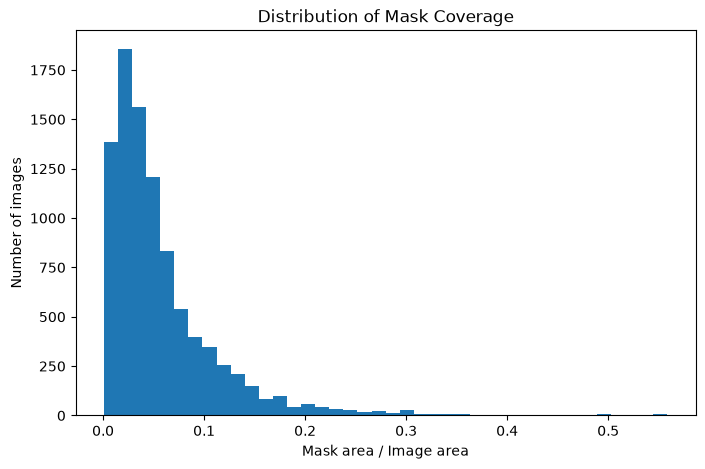

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["mask_ratio"], bins=40)
plt.xlabel("Mask area / Image area")
plt.ylabel("Number of images")
plt.title("Distribution of Mask Coverage")
plt.show()

# 1.4 Kiểm tra format của dataset

In [9]:
from collections import Counter
from PIL import Image
format_counter = Counter()

for img_path in DATA_PATH.glob("*.*"):
    try:
        with Image.open(img_path) as img:
            format_counter[img.format] += 1
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")

print("Thống kê format thực tế của các file:")
for fmt, count in format_counter.items():
    print(f"- {fmt}: {count} file")

Thống kê format thực tế của các file:
- JPEG: 9273 file


# 1.5 Kiểm tra ảnh có trùng lặp

In [10]:
import hashlib
from collections import defaultdict

hash_dict = defaultdict(list)
for img_path in DATA_PATH.glob("*.*"):
    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        hash_dict[file_hash].append(img_path.name)

duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

if duplicates:
    print("Phát hiện các file trùng lặp chính xác:")
    for h, files in duplicates.items():
        print(f"- Nhóm trùng ({h}): {files}")
else:
    print("Không tìm thấy file nào trùng lặp chính xác.")

Không tìm thấy file nào trùng lặp chính xác.


# 1.6 Visualize một số ảnh và mask

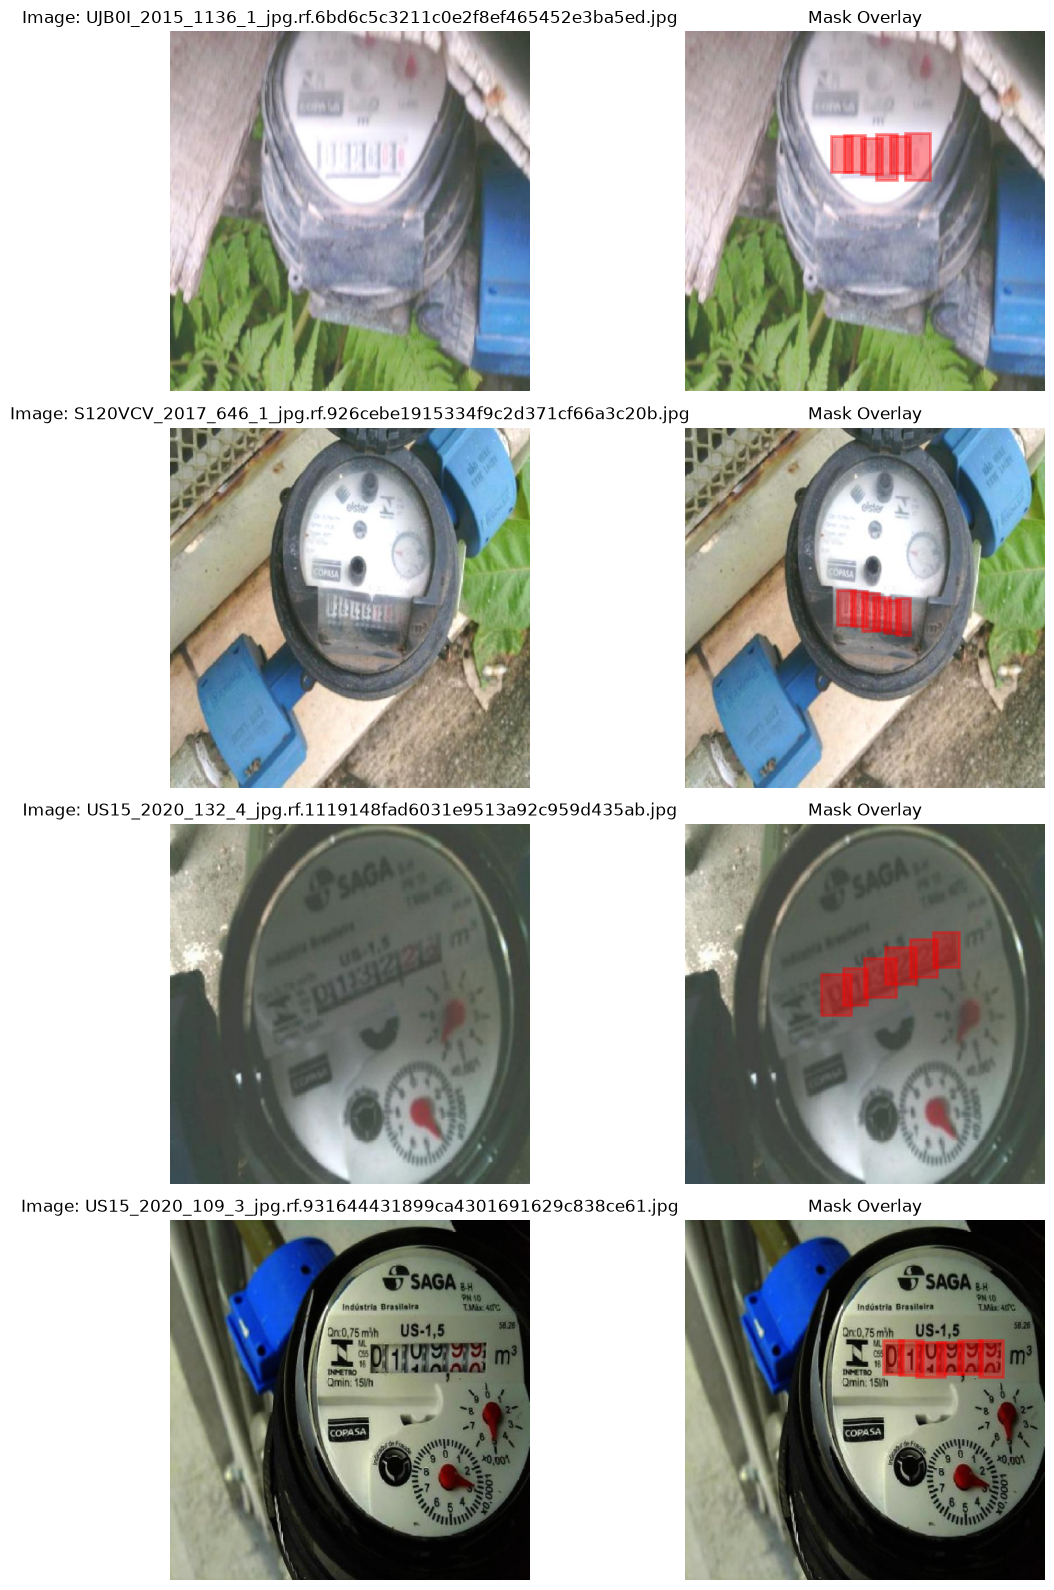

In [11]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

image_files = sorted(list(DATA_PATH.glob("*.*")))
labels_dir = DATA_PATH.parent / "labels"

random.seed(42)
sample_files = random.sample(image_files, min(4, len(image_files)))

fig, axes = plt.subplots(len(sample_files), 2, figsize=(12, 4 * len(sample_files)))

for i, img_path in enumerate(sample_files):
    img = Image.open(img_path)
    w, h = img.size
    
    # Vẽ ảnh gốc
    ax_img = axes[i, 0] if len(sample_files) > 1 else axes[0]
    ax_img.imshow(img)
    ax_img.set_title(f"Image: {img_path.name}")
    ax_img.axis("off")
    
    # Vẽ mask đè lên ảnh gốc
    ax_overlay = axes[i, 1] if len(sample_files) > 1 else axes[1]
    ax_overlay.imshow(img)
    ax_overlay.set_title("Mask Overlay")
    ax_overlay.axis("off")
    
    lbl_path = labels_dir / f"{img_path.stem}.txt"
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 7:
                    try:
                        coords = [float(x) for x in parts[1:]]
                        x_coords = [x * w for x in coords[0::2]]
                        y_coords = [y * h for y in coords[1::2]]
                        polygon = list(zip(x_coords, y_coords))
                        
                        # Thêm patch polygon màu đỏ trong suốt
                        patch = patches.Polygon(polygon, linewidth=2, edgecolor='red', facecolor='red', alpha=0.4)
                        ax_overlay.add_patch(patch)
                    except ValueError:
                        pass

plt.tight_layout()
plt.show()

### 1.7 Vẽ heatmap để xem vùng mask tập trung ở đâu nhiều nhất

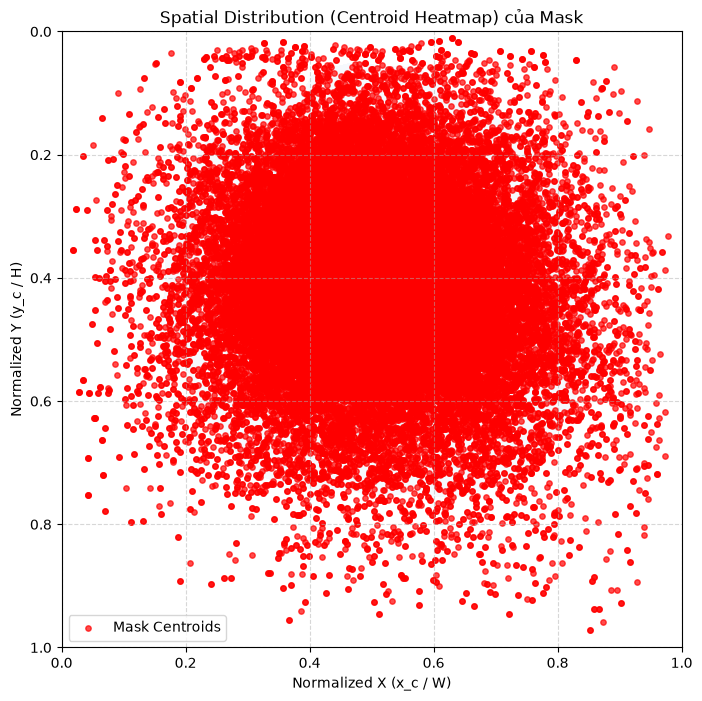

In [14]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

normalized_centroids = []
labels_dir = DATA_PATH.parent / "labels"

for lbl_path in labels_dir.glob("*.txt"):
    try:
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 7:
                    coords = [float(x) for x in parts[1:]]
                    x_c = np.mean(coords[0::2])
                    y_c = np.mean(coords[1::2])
                    normalized_centroids.append((x_c, y_c))
    except Exception as e:
        print(f"Lỗi đọc file {lbl_path.name}: {e}")

normalized_centroids = np.array(normalized_centroids)
x_coords = normalized_centroids[:, 0]
y_coords = normalized_centroids[:, 1]

# 2. Vẽ biểu đồ Scatter kết hợp Heatmap phân bố không gian
plt.figure(figsize=(8, 8))

# Tạo Heatmap mờ phía sau bằng KDE plot
sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap="Blues",
    fill=True,
    thresh=0.05,
    levels=10,
    alpha=0.6,
)

plt.scatter(
    x_coords, y_coords, color="red", s=15, alpha=0.7, label="Mask Centroids"
)

plt.gca().invert_yaxis()

plt.xlim(0, 1)
plt.ylim(1, 0)  # Đảo ngược trục Y chuẩn ảnh
plt.xlabel("Normalized X (x_c / W)")
plt.ylabel("Normalized Y (y_c / H)")
plt.title("Spatial Distribution (Centroid Heatmap) của Mask")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### 1.8 Kiểm tra lỗi segmentation

In [16]:
def polygon_area(coords):
    n = len(coords) // 2
    x = coords[0::2]
    y = coords[1::2]
    return 0.5 * abs(sum(x[i]*y[(i+1)%n] - x[(i+1)%n]*y[i] for i in range(n)))

errors = {
    "too_small": [],  # Mask area < 0.1%
    "too_large": [],  # Mask area > 90%
    "touch_boundary": [],  # Mask chạm biên ảnh
    "multi_components": [],  # Có nhiều vùng rời rạc (Connected Components > 1)
}

labels_dir = DATA_PATH.parent / "labels"

for lbl_path in labels_dir.glob("*.txt"):
    try:
        with open(lbl_path, 'r') as f:
            lines = f.read().strip().split('\n')
        
        if not lines or (len(lines) == 1 and lines[0].strip() == ''):
            continue
            
        polygons_count = len(lines)
        if polygons_count > 1:
            errors["multi_components"].append((lbl_path.name, polygons_count))
            
        for line_idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) < 7:
                continue
                
            coords = [float(x) for x in parts[1:]]
            area = polygon_area(coords)
            
            # --- Kiểm tra lỗi 1: Mask quá nhỏ (< 0.1%) ---
            if area < 0.001:
                errors["too_small"].append((lbl_path.name, area * 100))
                
            # --- Kiểm tra lỗi 2: Mask quá lớn (> 90%) ---
            if area > 0.90:
                errors["too_large"].append((lbl_path.name, area * 100))
                
            # --- Kiểm tra lỗi 3: Mask chạm biên ---
            touch = False
            for coord in coords:
                if coord <= 0.005 or coord >= 0.995:
                    touch = True
                    break
            if touch:
                errors["touch_boundary"].append(lbl_path.name)
                
    except Exception as e:
        print(f"Lỗi xử lý file {lbl_path.name}: {e}")

# In kết quả báo cáo tổng kết
print(f"- Tổng số mask quá nhỏ (< 0.1%): {len(errors['too_small'])}")
print(f"- Tổng số mask quá lớn (> 90%): {len(errors['too_large'])}")
print(f"- Tổng số mask chạm biên: {len(errors['touch_boundary'])}")
print(f"- Tổng số mask có nhiều vùng rời rạc (>1): {len(errors['multi_components'])}")

# Ví dụ hiển thị chi tiết một vài lỗi (nếu có)
if errors["multi_components"]:
    print("\nChi tiết các file có nhiều connected components:")
    for name, count in errors["multi_components"][:5]:
        print(f"  + File: {name} (Có {count} vùng)")

- Tổng số mask quá nhỏ (< 0.1%): 2001
- Tổng số mask quá lớn (> 90%): 0
- Tổng số mask chạm biên: 435
- Tổng số mask có nhiều vùng rời rạc (>1): 9273

Chi tiết các file có nhiều connected components:
  + File: US15_2021_3_2_jpg.rf.f7ba3a83f23d3cd85c5262db4743a7a3.txt (Có 6 vùng)
  + File: US15_2020_134_7_jpg.rf.c82bfab6e9885a7fe6f377b170c287d7.txt (Có 6 vùng)
  + File: UJB0ICV_2015_429_1_jpg.rf.4ea596fc4f76cf4cb99d354320ca0f31.txt (Có 5 vùng)
  + File: US15_2020_36_1_jpg.rf.7b296fc98066de86f547f89b900a5d34.txt (Có 6 vùng)
  + File: US15_2020_107_2_jpg.rf.42069760b6cc73e35f202359f092f524.txt (Có 6 vùng)
